In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# Get data from arrayExpress: VAKPS VKPN MDO tumors

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16835"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16835 in: ../data_arrayExpress/E-MTAB-16835
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16835
      Inferred 2 dataset representations:
      - epi (full prefix: AKPS_KPN_epi)
      - full (full prefix: AKPS_KPN_full)
      No dataset specified. Automatically selected for in-memory loading: epi (full prefix: AKPS_KPN_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_full.h5ad
      Loading selected dataset from disk: E-MTAB-16835/E-MTAB-16835_epi.h5ad


AnnData object with n_obs × n_vars = 1573 × 18791
    obs: 'sample_id', 'library_id', 'line', 'replicate', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## UMAP representation

UMAP was not changed after doing proper QC on dataset... Exchange in Ext Fig 2d

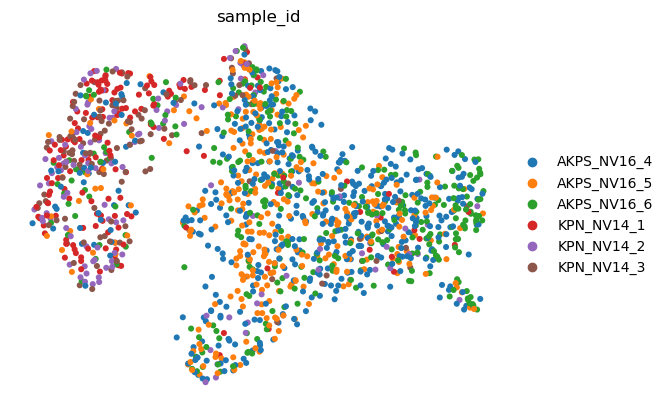

In [4]:
# Annotation UMAP
sc.pl.umap(adata, color='sample_id', frameon=False, title=None)

## Marker gene distribution

/tmp/ipykernel_3898726/2831618723.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


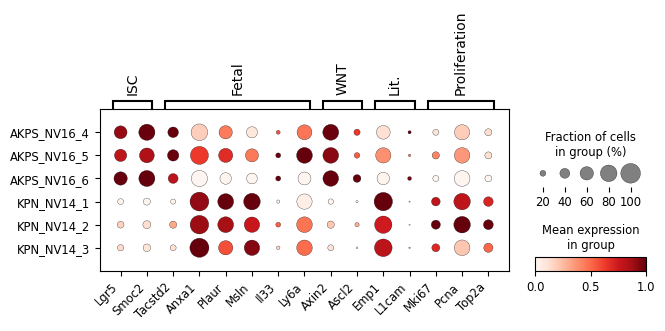

In [14]:
# Make dotplot over feature
marker_genes_dict = {
    "ISC": ["Lgr5", "Smoc2"],
    "Fetal": ["Tacstd2", "Anxa1", "Plaur", "Msln", "Il33", "Ly6a"],
    "WNT": ["Axin2", "Ascl2"],
    "Lit.": ["Emp1", "L1cam"],
    "Proliferation": ["Mki67", "Pcna", "Top2a"],
}

sample_id_dict = {
    'AKPS_NV16_4': 'VAKPS #1',
    'AKPS_NV16_5': 'VAKPS #2',
    'AKPS_NV16_6': 'VAKPS #3',
    'KPN_NV14_1': 'VKPN #1',
    'KPN_NV14_2': 'VKPN #2',
    'KPN_NV14_3': 'VKPN #3'
}

dp = sc.pl.dotplot(
    adata,
    marker_genes_dict,
    groupby="sample_id",
    standard_scale="var",
    swap_axes=False,
    show=False,
)

ax = dp["mainplot_ax"]

ax.set_xticklabels(
    [sample_id_dict.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

sample id labels are not matching yet

## Continue with GSEA